In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


# first Cleaning Data

# dataset summary
1. OrderID - it is an unique id which helps to track every order
2. Date - It describes the date od the Order
3. CustomerID - is is an unique id for each customer, which gives info about the customer.
4. Product - it is the type of product the order has been placed of, it is categorical and does not have huge varities
5. Quantity - the quantity of product ordered
6. UnitPrice - The price of the single product ordered
7. ShippingAddress - it is the address where order has to be delivered
8. PaymentMethod - the method used by the customer to pay for the product they ordered
9. OrderStatus - it is the track of the order, it describes the progress of the order delivery
10. TrackingNumber - the number used by the customer to track the delivery progress of the order, it addresses how much the order have been traveled from the starting point to the destination
11. ItemsInCart - the total number of items ordered by that customer, product type can vary
12. CouponCode - the type of Coupon code used by the customer, it's not used by every customer
13. ReferralSource - it describes the source from which they get to know about this
14. TotalPRice - the final amount customer pays for the order
    

In [3]:
df[df['OrderID'].duplicated()]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [7]:
df[df['CustomerID'].duplicated()]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
602,ORD200602,2024-03-05,C35852,Tablet,4,26.04,982 Main St,Online,Pending,TRK64660134,5,SAVE10,Instagram,104.16
664,ORD200664,2024-12-19,C14847,Laptop,4,194.75,188 Main St,Cash,Shipped,TRK46492755,5,NaN,Facebook,779.00
712,ORD200712,2024-01-09,C56969,Tablet,2,68.40,993 Main St,Gift Card,Pending,TRK10513339,7,FREESHIP,Email,136.80
801,ORD200801,2023-05-03,C97593,Printer,4,595.62,738 Main St,Debit Card,Pending,TRK58443593,8,FREESHIP,Facebook,2382.48
941,ORD200941,2023-07-17,C91155,Printer,5,111.70,599 Main St,Credit Card,Cancelled,TRK82162952,9,FREESHIP,Email,558.50
948,ORD200948,2024-06-21,C94569,Phone,2,594.07,739 Main St,Gift Card,Cancelled,TRK79269291,2,NaN,Google,1188.14
956,ORD200956,2024-04-11,C21191,Phone,2,160.98,381 Main St,Debit Card,Delivered,TRK86246309,3,SAVE10,Referral,321.96
1007,ORD201007,2024-03-20,C46651,Monitor,2,73.26,839 Main St,Cash,Pending,TRK60444502,4,WINTER15,Facebook,146.52
1102,ORD201102,2024-06-03,C98474,Chair,4,347.17,997 Main St,Debit Card,Shipped,TRK86192984,8,NaN,Instagram,1388.68
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NaN,Facebook,3390.95


In [8]:
df[df['Quantity'].isnull()]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [9]:
df[df['UnitPrice'].isnull()]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [10]:
df[df['ShippingAddress'].isnull()]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [11]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [12]:
df.columns = df.columns.str.replace(r'([a-z0-9])([A-Z])', r'\1 \2', regex=True)

In [13]:
df.sample()

,Order ID,Date,Customer ID,Product,Quantity,Unit Price,Shipping Address,Payment Method,Order Status,Tracking Number,Items In Cart,Coupon Code,Referral Source,Total Price
473,ORD200473,2025-02-25,C28552,Chair,2,14.93,449 Main St,Online,Shipped,TRK71597160,4,NaN,Facebook,29.86


In [14]:
df[['Order Status','Payment Method','Product','Referral Source']]=df[['Order Status','Payment Method','Product','Referral Source']].astype('category')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          1200 non-null   object        
 1   Date              1200 non-null   datetime64[ns]
 2   Customer ID       1200 non-null   object        
 3   Product           1200 non-null   category      
 4   Quantity          1200 non-null   int64         
 5   Unit Price        1200 non-null   float64       
 6   Shipping Address  1200 non-null   object        
 7   Payment Method    1200 non-null   category      
 8   Order Status      1200 non-null   category      
 9   Tracking Number   1200 non-null   object        
 10  Items In Cart     1200 non-null   int64         
 11  Coupon Code       891 non-null    object        
 12  Referral Source   1200 non-null   category      
 13  Total Price       1200 non-null   float64       
dtypes: category(4), datetime

In [16]:
df['Coupon Code'].value_counts()

Coupon Code
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [17]:
df['Coupon Code'] = df['Coupon Code'].astype('category')

In [18]:
df.describe()

,Date,Quantity,Unit Price,Items In Cart,Total Price
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [19]:
df[df['Unit Price'] == 699.930000]

,Order ID,Date,Customer ID,Product,Quantity,Unit Price,Shipping Address,Payment Method,Order Status,Tracking Number,Items In Cart,Coupon Code,Referral Source,Total Price
742,ORD200742,2024-11-30,C41974,Laptop,3,699.93,726 Main St,Cash,Returned,TRK48051468,7,SAVE10,Google,2099.79


In [20]:
df.set_index('Order ID', inplace = True)

In [21]:
df.to_csv('data cleaned')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200 entries, ORD200000 to ORD201199
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1200 non-null   datetime64[ns]
 1   Customer ID       1200 non-null   object        
 2   Product           1200 non-null   category      
 3   Quantity          1200 non-null   int64         
 4   Unit Price        1200 non-null   float64       
 5   Shipping Address  1200 non-null   object        
 6   Payment Method    1200 non-null   category      
 7   Order Status      1200 non-null   category      
 8   Tracking Number   1200 non-null   object        
 9   Items In Cart     1200 non-null   int64         
 10  Coupon Code       891 non-null    category      
 11  Referral Source   1200 non-null   category      
 12  Total Price       1200 non-null   float64       
dtypes: category(5), datetime64[ns](1), float64(2), int64(2), object(3)
mem

# EDA

In [23]:
df['Total Price'].describe()

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: Total Price, dtype: float64

Text(0.5, 1.0, 'Product ')

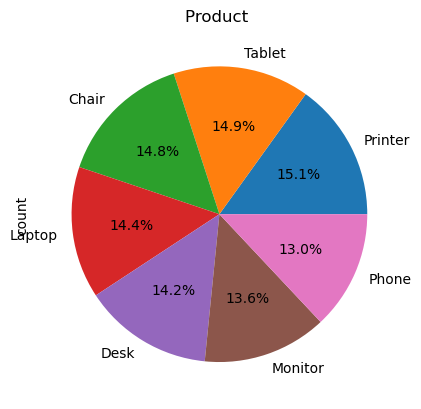

In [24]:
df['Product'].value_counts().plot(kind = 'pie', autopct = '%0.1f%%')
plt.title('Product ')

Text(0.5, 1.0, ' Payment Method used by the Customer')

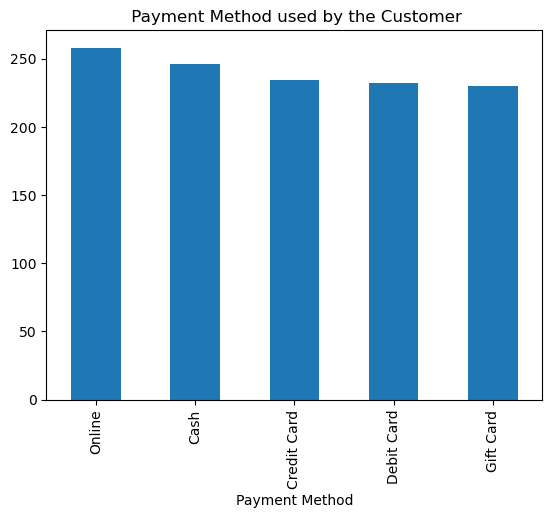

In [25]:
df['Payment Method'].value_counts().plot(kind = 'bar')
plt.title(' Payment Method used by the Customer')

Text(0.5, 1.0, 'Order Status')

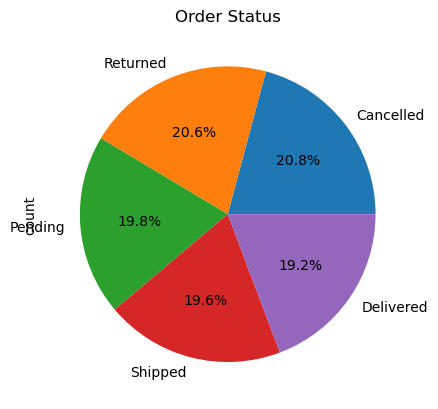

In [26]:
df['Order Status'].value_counts().plot(kind='pie', autopct = '%0.1f%%')
plt.title('Order Status')

Text(0.5, 1.0, 'Total Customer Order Price of Each Customer')

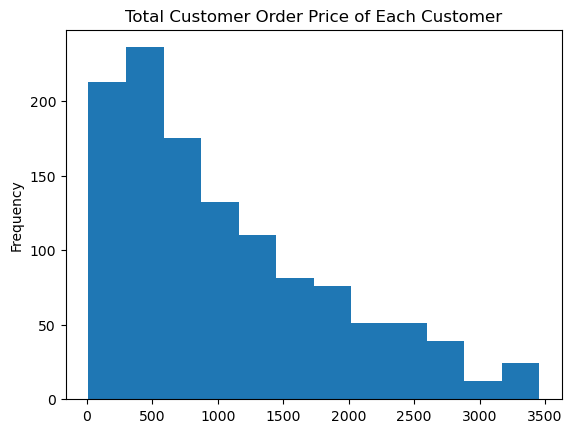

In [27]:
df['Total Price'].plot(kind = 'hist', bins=12)
plt.title('Total Customer Order Price of Each Customer')

Text(0.5, 1.0, 'Referred Sources')

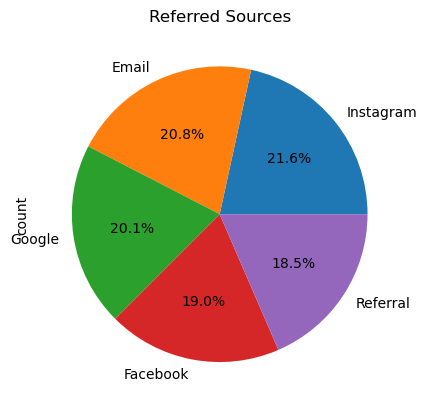

In [28]:
df['Referral Source'].value_counts().plot(kind = 'pie', autopct ='%0.1f%%')
plt.title('Referred Sources')

C:\Users\23shr\AppData\Local\Temp\ipykernel_23292\1023057308.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Product')['Quantity'].sum().plot()


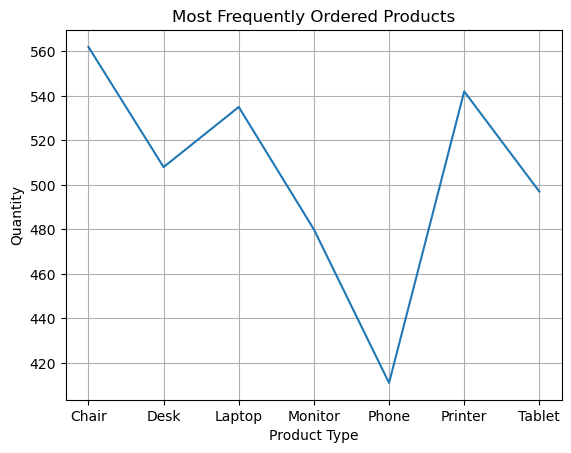

In [29]:
# what products are most frequently ordered
df.groupby('Product')['Quantity'].sum().plot()
plt.title('Most Frequently Ordered Products')
plt.xlabel("Product Type")
plt.ylabel('Quantity')
plt.grid()

C:\Users\23shr\AppData\Local\Temp\ipykernel_23292\450980304.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Product')['Total Price'].sum().plot(kind = 'bar')


<Axes: xlabel='Product'>

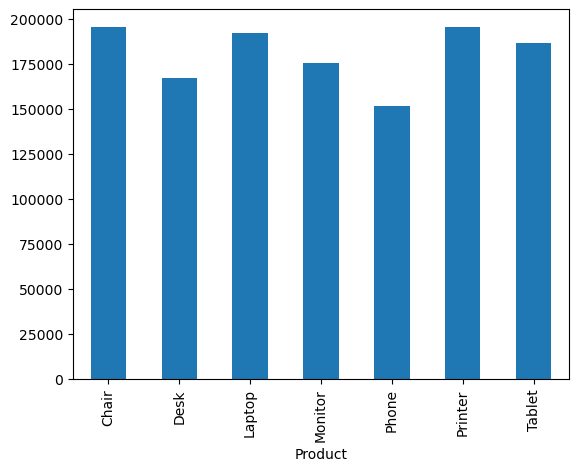

In [30]:
# Which Product generates the highest average TotalPrice
df.groupby('Product')['Total Price'].sum().plot(kind = 'bar')


C:\Users\23shr\AppData\Local\Temp\ipykernel_23292\826541494.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Referral Source')['Total Price'].sum().plot()


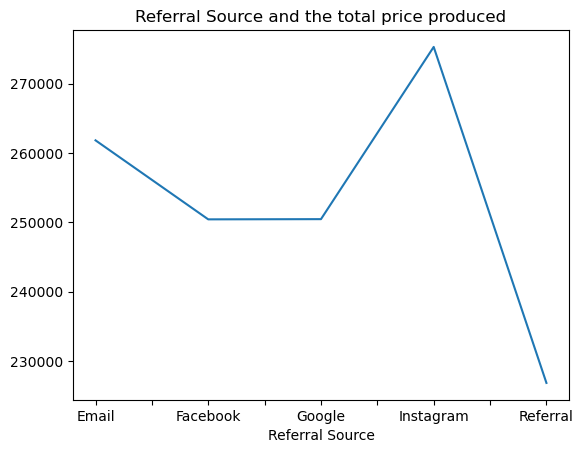

In [31]:
# Which ReferralSource leads to the highest average spend per order?
df.groupby('Referral Source')['Total Price'].sum().plot()
plt.title('Referral Source and the total price produced')
plt.show()

<Axes: xlabel='Product'>

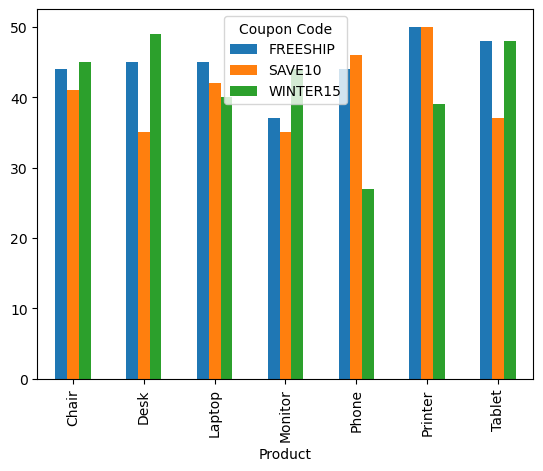

In [32]:
pd.crosstab(df['Product'],df['Coupon Code']).plot(kind ='bar')

<Axes: xlabel='Product'>

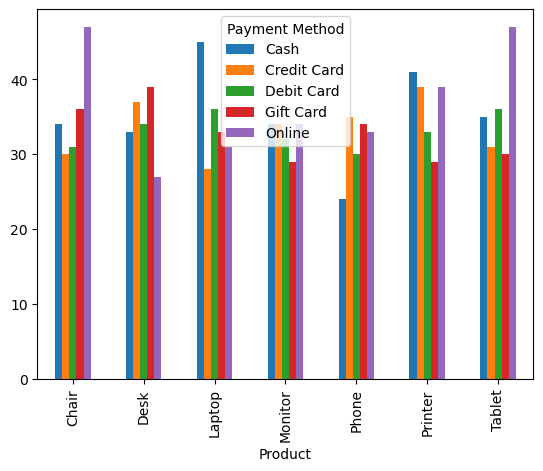

In [33]:
pd.crosstab(df['Product'] , df['Payment Method']).plot(kind = 'bar')

<Axes: xlabel='Product'>

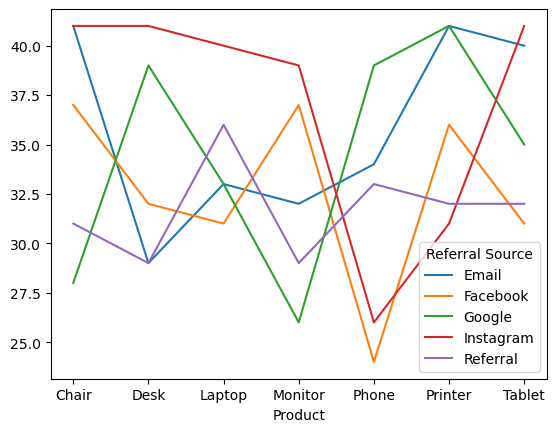

In [34]:
pd.crosstab(df['Product'] , df['Referral Source']).plot()

Text(0.5, 1.0, 'Track Number with te')

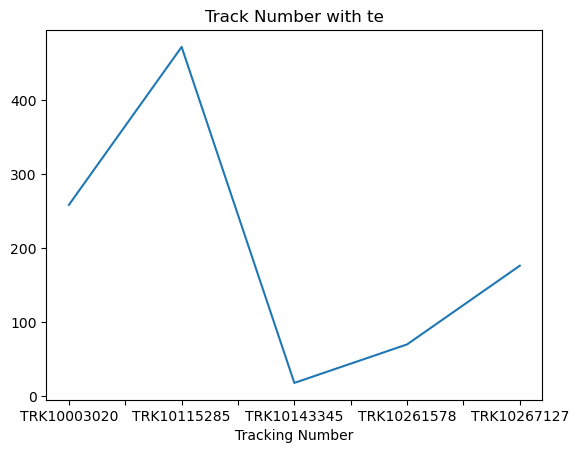

In [35]:
df.groupby('Tracking Number')['Total Price'].sum().head().plot()
plt.title('Track Number with te')

Text(0.5, 1.0, 'Dates with the most maximum total price')

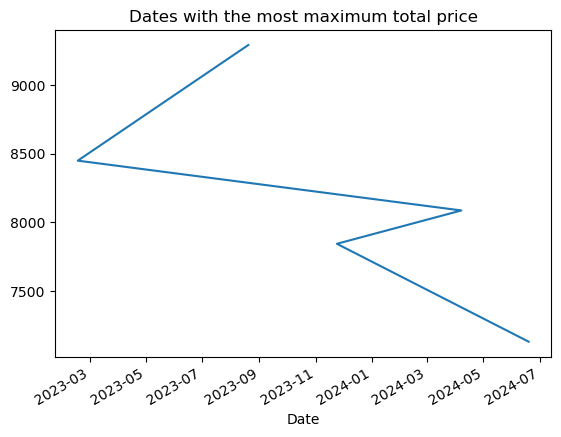

In [36]:
df.groupby('Date')['Total Price'].sum().sort_values(ascending = False).head().plot()
plt.title('Dates with the most maximum total price')

In [37]:
df.to_csv('df_cleaned')